In [ ]:
!pip install ultralytics supervision opencv-python-headless

In [ ]:

from ultralytics import YOLO
import supervision as sv
import cv2
import numpy as np


In [ ]:

from google.colab import files
uploaded = files.upload()

Saving Basketball.mp4 to Basketball.mp4
Saving Cricket.mp4 to Cricket.mp4
Saving Football.mp4 to Football.mp4
Saving Netball.mp4 to Netball.mp4
Saving Relay.mp4 to Relay.mp4


In [ ]:
video_path = list(uploaded.keys())[1]

In [ ]:
model = YOLO("yolov8n.pt")

In [ ]:
tracker = sv.ByteTrack()
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

In [ ]:
video_info = sv.VideoInfo.from_video_path(video_path)
print(video_info)

VideoInfo(width=720, height=1280, fps=30.0, total_frames=320)


In [ ]:

output_path = "tracked_output.mp4"
sink = sv.VideoSink(output_path, video_info)
sink.__enter__()

In [ ]:
frame_generator = sv.get_video_frames_generator(video_path)
for frame in frame_generator:
    results = model(frame, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = detections[detections.class_id == 0]
    detections = tracker.update_with_detections(detections)
    labels = [
        f"Player {tracker_id}"
        for tracker_id in detections.tracker_id
    ]
    annotated = box_annotator.annotate(
        scene=frame,
        detections=detections
    )
    annotated = label_annotator.annotate(
        scene=annotated,
        detections=detections,
        labels=labels
    )
    sink.write_frame(annotated)
sink.__exit__(None, None, None)
print("Finished")

Finished


In [ ]:
files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
pose_model = YOLO("yolov8n-pose.pt")

In [ ]:
results = pose_model(frame)[0]


0: 640x384 2 persons, 145.4ms
Speed: 3.6ms preprocess, 145.4ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)



0: 640x384 2 persons, 147.2ms
Speed: 19.8ms preprocess, 147.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 384)


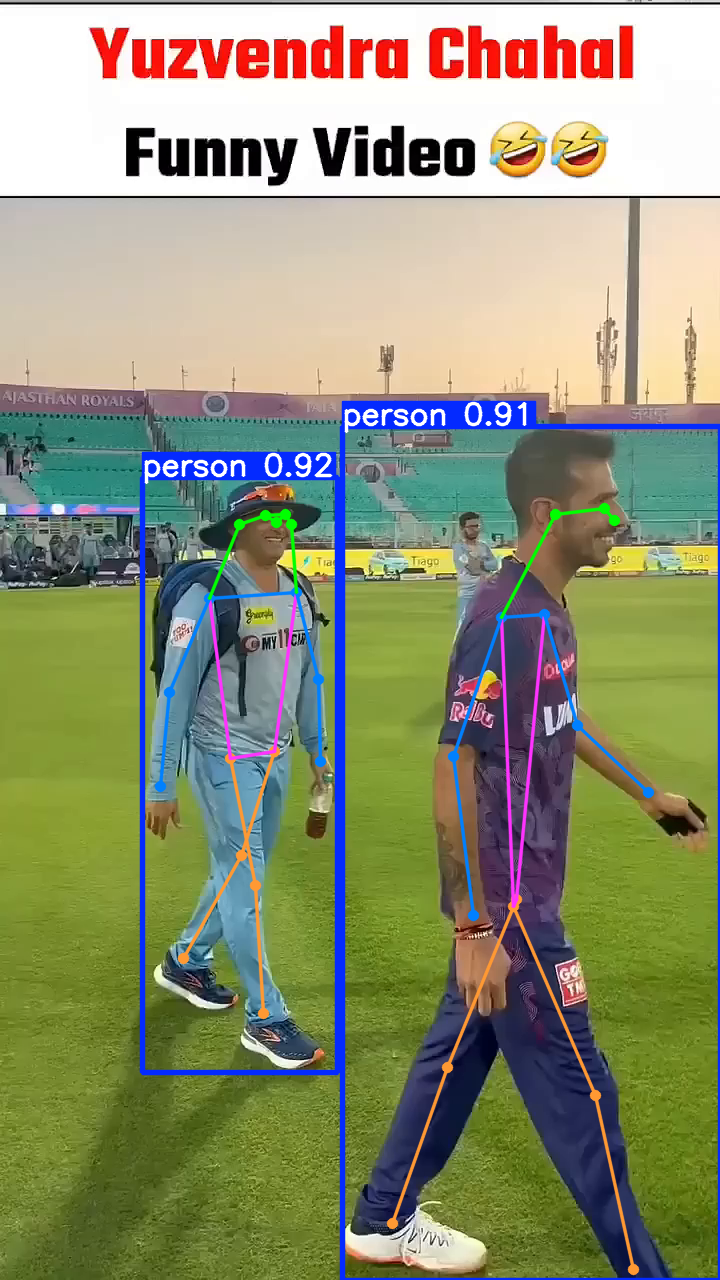

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
if ret:
    results = pose_model(frame)
    annotated_frame = results[0].plot()
    cv2_imshow(annotated_frame)
cap.release()

In [ ]:
results = pose_model.predict(
    source=video_path,
    save=True,
    conf=0.3
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/320) /content/Cricket.mp4: 640x384 2 persons, 142.2ms
video 1/1 (frame 2/320) /content/Cricket.mp4: 640x384 2 persons, 158.6ms
video 1/1 (frame 3/320) /content/Cricket.mp4: 640x384 3 persons, 141.9ms
video 1/1 (frame 4/320) /content/Cricket.mp4: 640x384 3 persons, 132.6ms
video 1/1 (frame 5/320) /content/Cricket.mp4: 640x384 3 persons, 136.2ms
video 1/1 (frame 6/320) /content/Cricket.mp4: 640x384 3 persons, 153.4ms
video 1/1 (frame 7/3

In [ ]:
from google.colab import files

files.download("runs/pose/predict/Cricket.avi")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO

# =====================================================================
# 1. VALIDATE DETECTOR (yolov8n.pt)
# =====================================================================
print("--- Validating Player Detection Model ---")
det_model = YOLO("yolov8n.pt")

# Runs validation on the benchmark COCO8 dataset
det_metrics = det_model.val(data="coco8.yaml", plots=True)

print("\n[DETECTION METRICS SUMMARY]")
print(f"Box Precision (P)    : {det_metrics.box.mp:.4f}")
print(f"Box Recall (R)       : {det_metrics.box.mr:.4f}")
print(f"Box mAP @ 50         : {det_metrics.box.map50:.4f}")
print(f"Box mAP @ 50-95      : {det_metrics.box.map:.4f}")


# =====================================================================
# 2. VALIDATE POSE ESTIMATOR (yolov8n-pose.pt)
# =====================================================================
print("\n--- Validating Keypoint/Pose Model ---")
pose_model = YOLO("yolov8n-pose.pt")

# Runs validation on the benchmark COCO8-Pose dataset
pose_metrics = pose_model.val(data="coco8-pose.yaml", plots=True)

print("\n[POSE METRICS SUMMARY]")
print(f"Pose Precision (P)   : {pose_metrics.pose.mp:.4f}")
print(f"Pose Recall (R)      : {pose_metrics.pose.mr:.4f}")
print(f"Pose mAP @ 50        : {pose_metrics.pose.map50:.4f}")
print(f"Pose mAP @ 50-95     : {pose_metrics.pose.map:.4f}")


# =====================================================================
# 3. LOCATE YOUR PLOTS & CURVES FOR THE REPORT
# =====================================================================
print("\n--- Validation Run Directories ---")
print(f"Detection plots saved in: {det_metrics.save_dir}")
print(f"Pose plots saved in:      {pose_metrics.save_dir}")

--- Validating Player Detection Model ---
Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

WARNING ⚠️ Dataset 'coco8.yaml' images not found, missing path '/content/datasets/coco8/images/val'
Unzipping /content/datasets/coco8.zip to /content/datasets/coco8...: 100% ━━━━━━━━━━━━ 25/25 253.4files/s 0.1s
Dataset download success ✅ (0.4s), saved to /content/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 994.6±450.3 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco8/labels/val... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 305.6it/s 0.0s
val: New cache created: /content/datasets/coco8/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.8s/it 1.8s
                   all          4         17      0.621      0.833      0.888      0.629
                person        